In [45]:
import importlib
import bsp_trade_labeling

bsp_trade_labeling = importlib.reload(
    bsp_trade_labeling
)

# ---------------------------------------
# Technical indicator controls
# ---------------------------------------

technical_windows = (
    20,
    39,
    78,
    156,
    200,
    390,
)

technical_rsi_periods = (
    14,
    78,
    156,
)

technical_atr_periods = (
    14,
    78,
    156,
)

technical_macd_periods = (
    (12, 26, 9),
    (39, 78, 20),
    (78, 156, 39),
)


# ---------------------------------------
# Train separate buy and sell models
# ---------------------------------------

trade_model_report = (
    bsp_trade_labeling.train_bsp_trade_models(
        labeled_path=(
            "outputs/"
            "bsp_trade_labels_TQQQ_5m_"
            "2012-2026_training.csv"
        ),
        output_dir=(
            "outputs/"
            "bsp_trade_models_by_type_and_direction"
        ),

        train_start_date="2012-01-01",
        train_end_date="2023-12-31",

        validation_start_date="2024-01-01",
        validation_end_date="2024-12-31",

        test_start_date="2025-01-01",
        test_end_date="2026-08-01 23:59:59",

        bsp_types=(
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        ),

        # New control
        separate_buy_sell=True,

        # Minimum is now checked separately for each
        # type/direction combination.
        minimum_rows_per_type=200,

        probability_threshold=0.50,
        include_delay_features=False,

        price_csv="DataAPI/data/TQQQ_5M.csv",
        price_progress_lookback_bars=390,
        minimum_structure_pct=0.002,

        include_multihorizon_technical_features=True,

        technical_windows=technical_windows,
        technical_rsi_periods=technical_rsi_periods,
        technical_atr_periods=technical_atr_periods,
        technical_macd_periods=technical_macd_periods,

        xgboost_params={
            "n_estimators": 400,
            "max_depth": 4,
            "learning_rate": 0.025,

            "min_child_weight": 8,
            "gamma": 0.0,

            "subsample": 0.80,
            "colsample_bytree": 0.65,

            "reg_alpha": 0.20,
            "reg_lambda": 3.0,

            # Prefer precision rather than forcing
            # additional positive predictions.
            "scale_pos_weight": 1.0,

            "n_jobs": 1,
            "random_state": 42,
        },

        verbose=True,
    )
)

trade_model_report

[Trade maturity 1_buy] test rows=1,279, precision=0.795, recall=0.754, PR-AUC=0.886
[Trade maturity 1_sell] test rows=1,699, precision=0.748, recall=0.703, PR-AUC=0.837
[Trade maturity 1p_buy] test rows=468, precision=0.729, recall=0.736, PR-AUC=0.822
[Trade maturity 1p_sell] test rows=885, precision=0.763, recall=0.663, PR-AUC=0.823
[Trade maturity 2_buy] test rows=1,094, precision=0.798, recall=0.813, PR-AUC=0.903
[Trade maturity 2_sell] test rows=1,372, precision=0.780, recall=0.743, PR-AUC=0.861
[Trade maturity 2s_buy] test rows=1,261, precision=0.739, recall=0.760, PR-AUC=0.871
[Trade maturity 2s_sell] test rows=1,479, precision=0.793, recall=0.710, PR-AUC=0.875


{'target': 'trade_maturity_target',
 'models': {'1_buy': {'train': {'rows': 8414,
    'positive_rate': 0.48740194913239837,
    'accuracy': 0.8142381744711196,
    'precision': 0.8486263736263736,
    'recall': 0.7532309192879786,
    'brier': 0.12786767704616067,
    'roc_auc': 0.9019157361708446,
    'pr_auc': 0.9115633467798255},
   'validation': {'rows': 852,
    'positive_rate': 0.5117370892018779,
    'accuracy': 0.7723004694835681,
    'precision': 0.8118556701030928,
    'recall': 0.7224770642201835,
    'brier': 0.14790602049288243,
    'roc_auc': 0.8640669107268879,
    'pr_auc': 0.8925466320110486},
   'test': {'rows': 1279,
    'positive_rate': 0.48944487881157156,
    'accuracy': 0.784206411258796,
    'precision': 0.7946127946127947,
    'recall': 0.7539936102236422,
    'brier': 0.1444626740572734,
    'roc_auc': 0.8719598412830436,
    'pr_auc': 0.8857896428505274},
   'feature_count': 96},
  '1_sell': {'train': {'rows': 12172,
    'positive_rate': 0.44175156095957935,


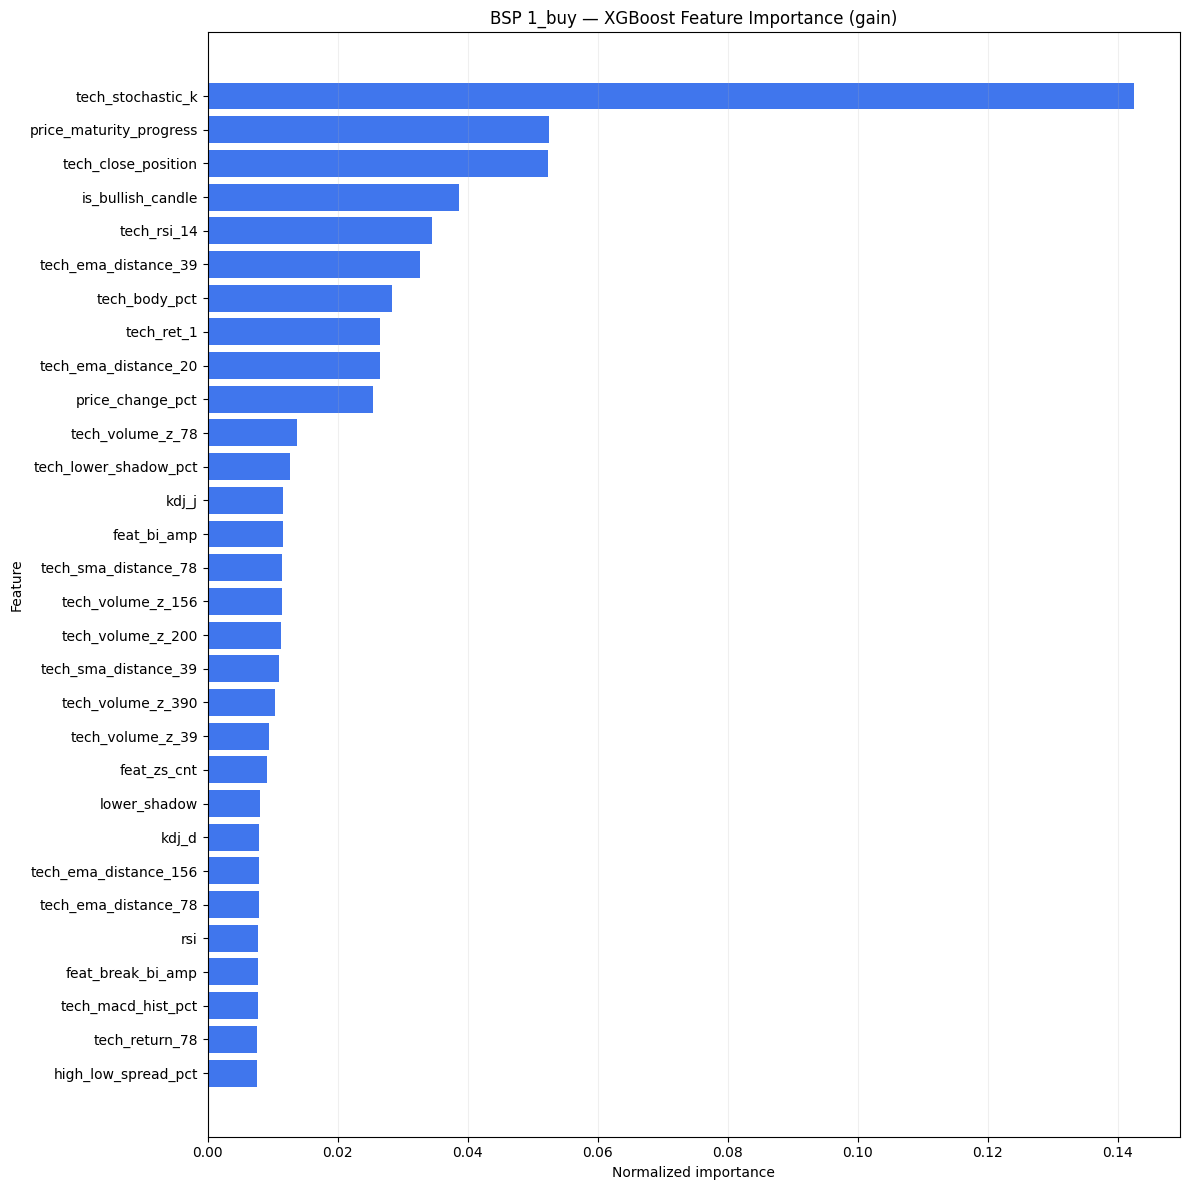

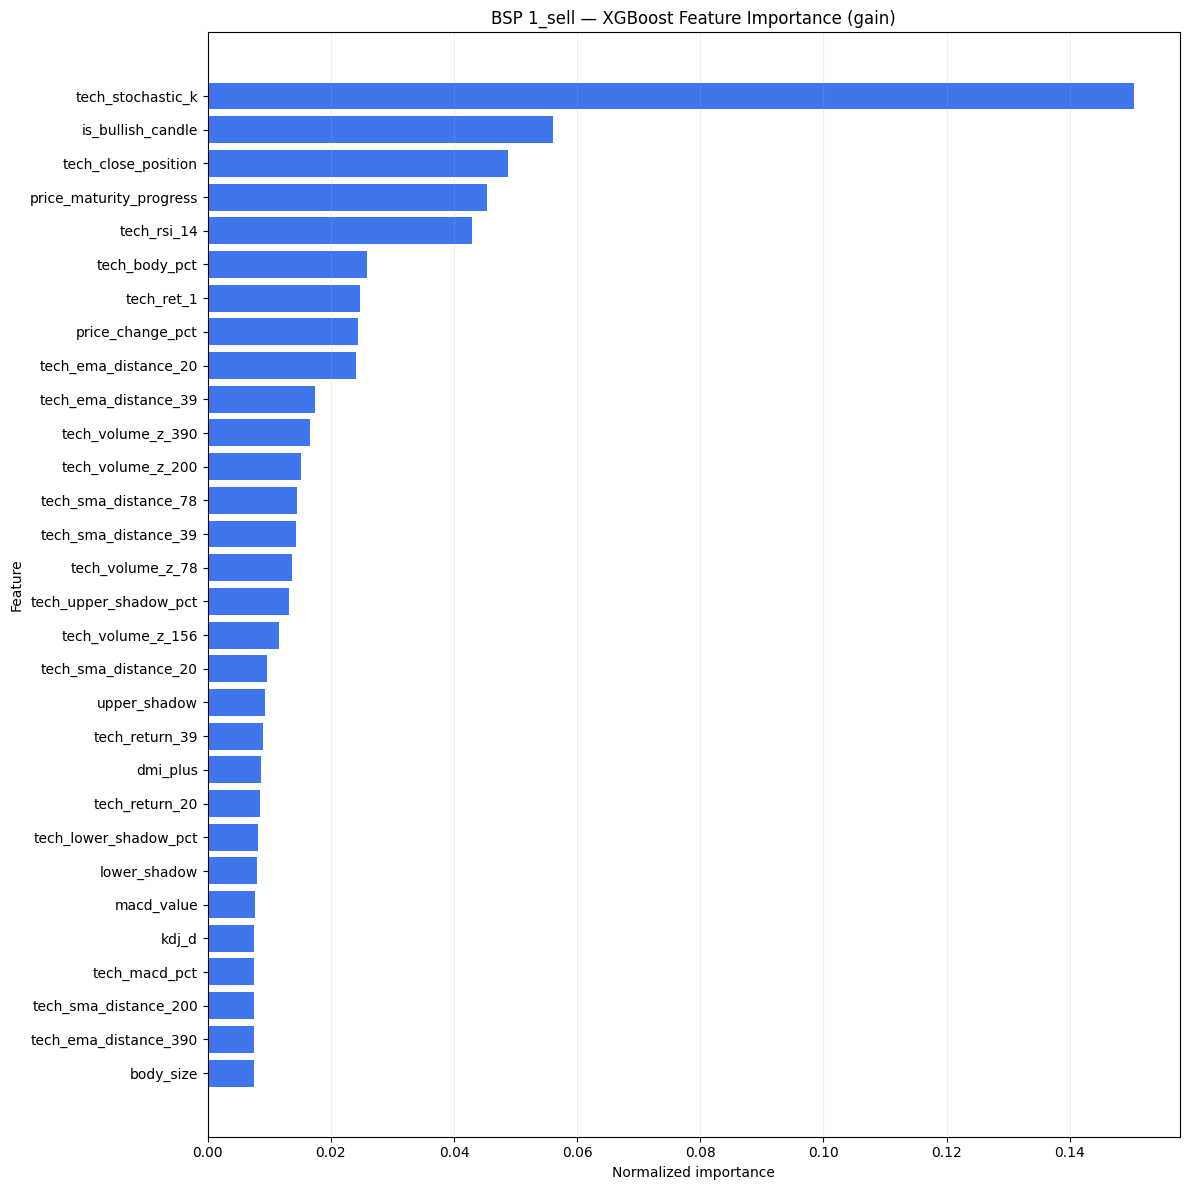

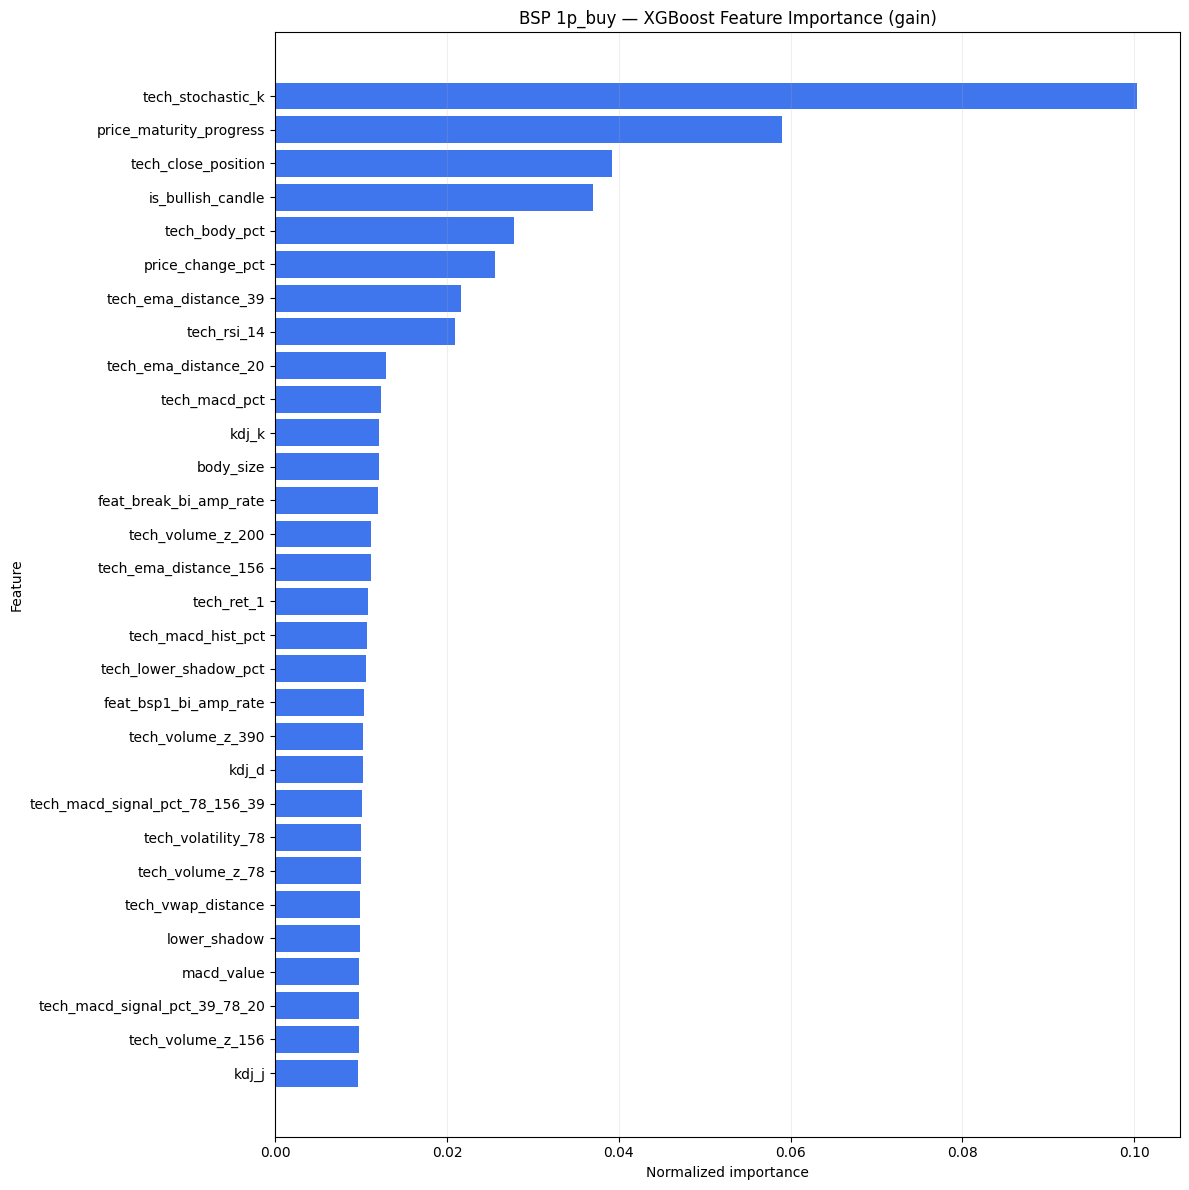

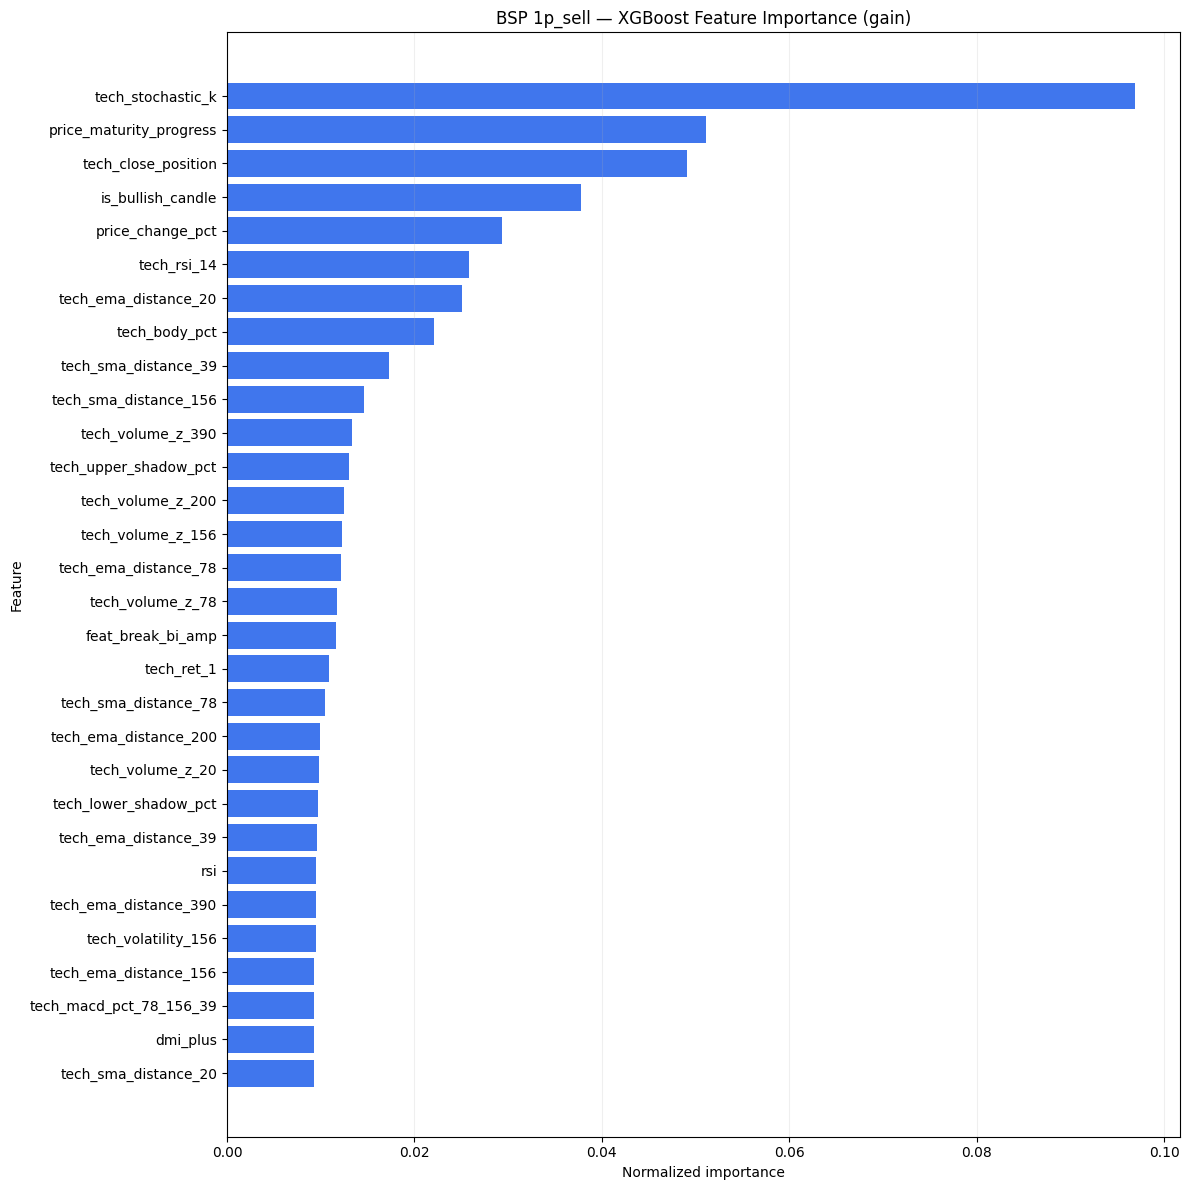

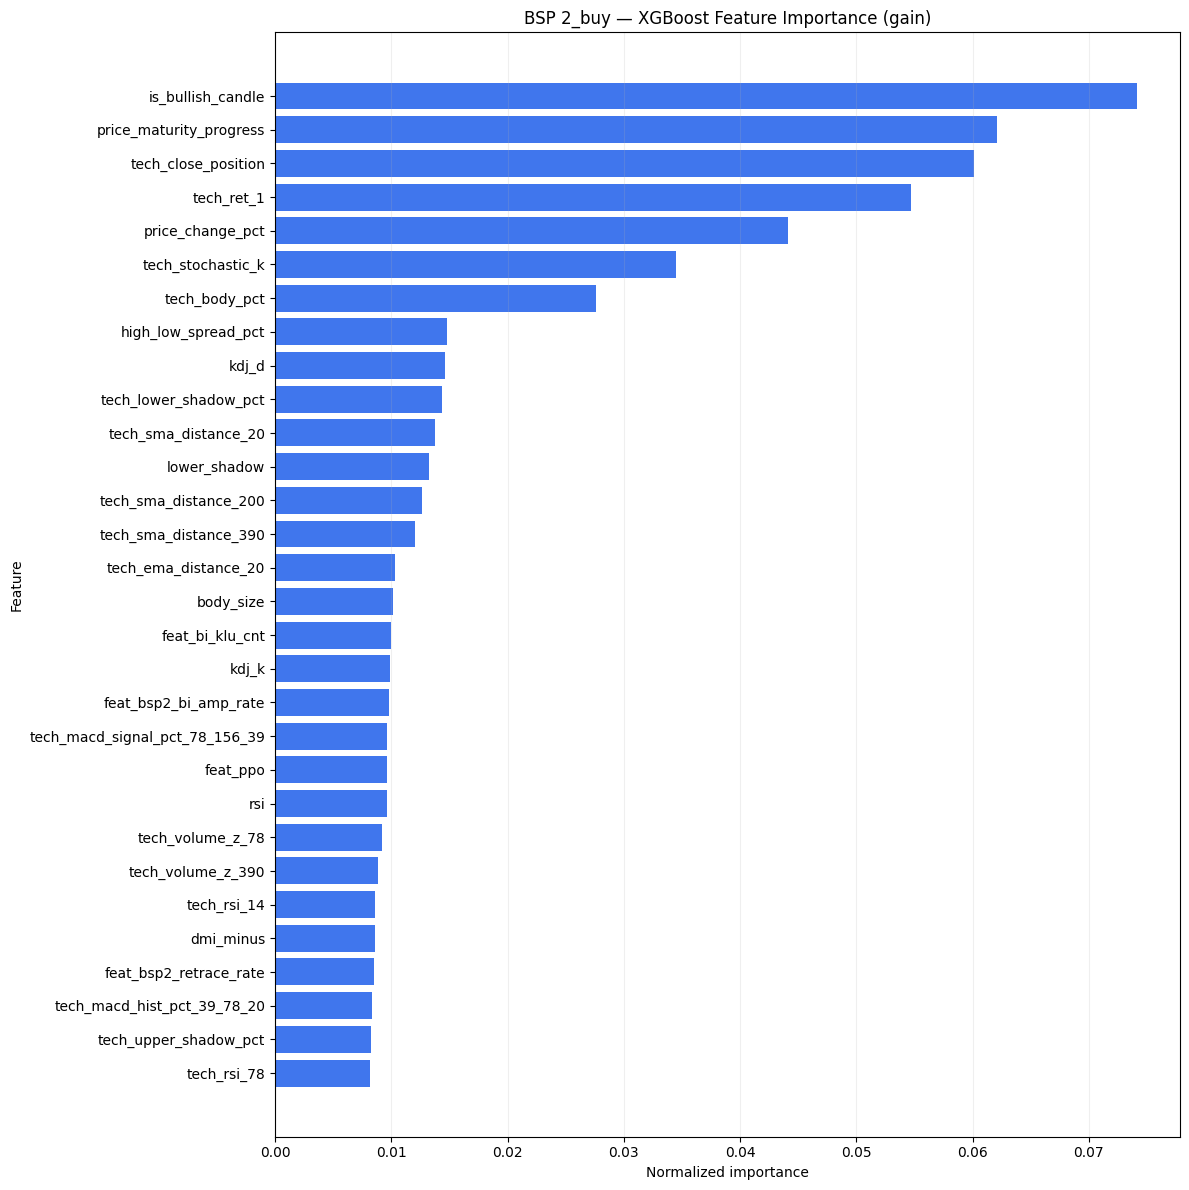

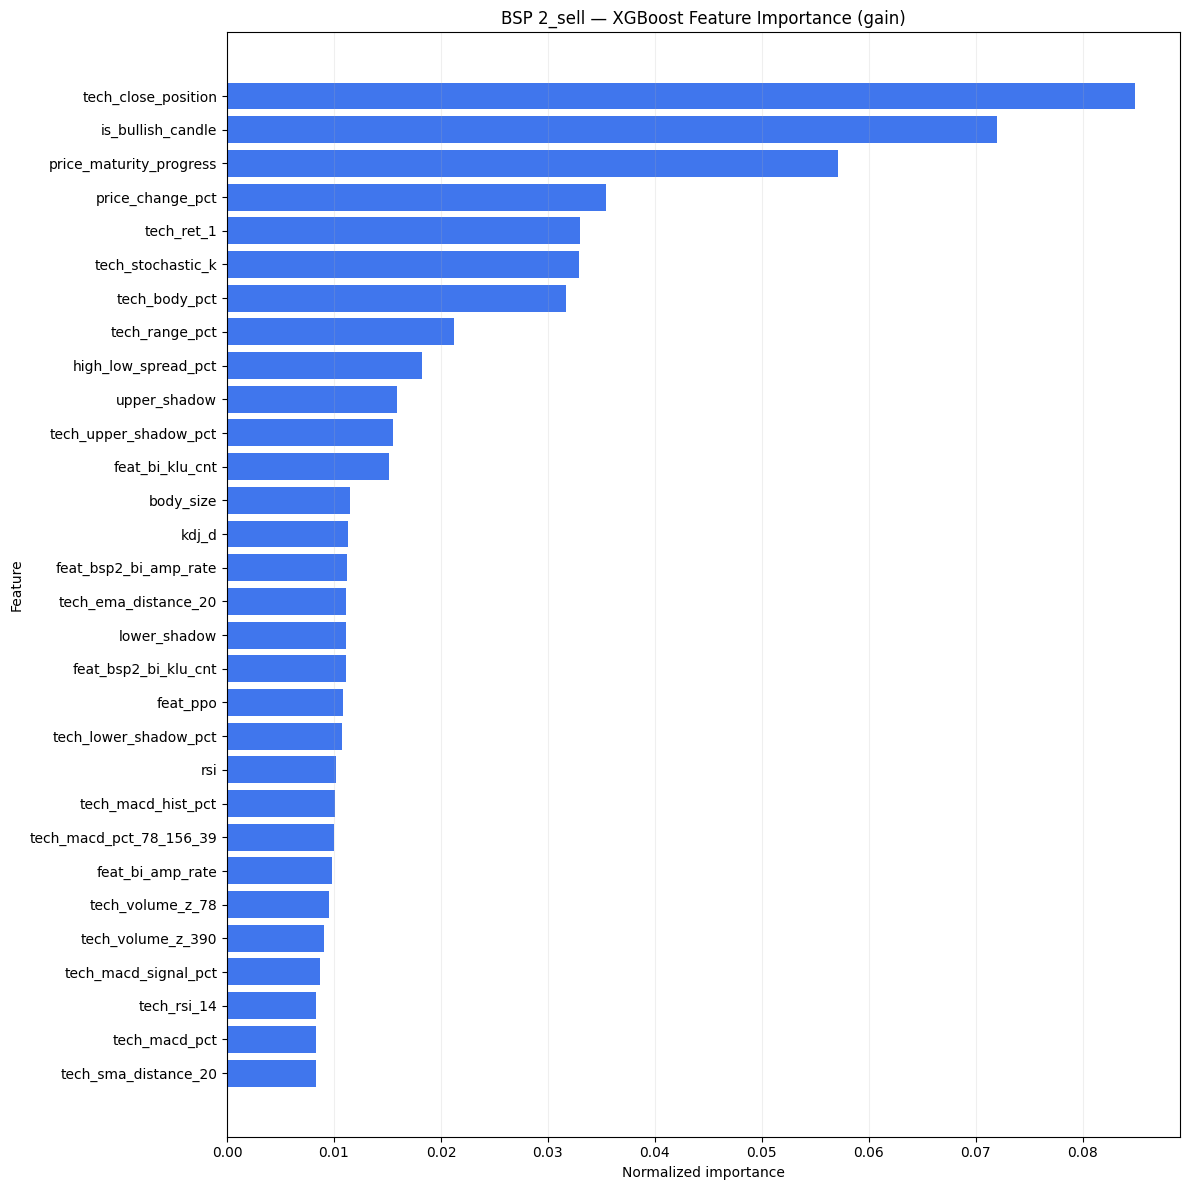

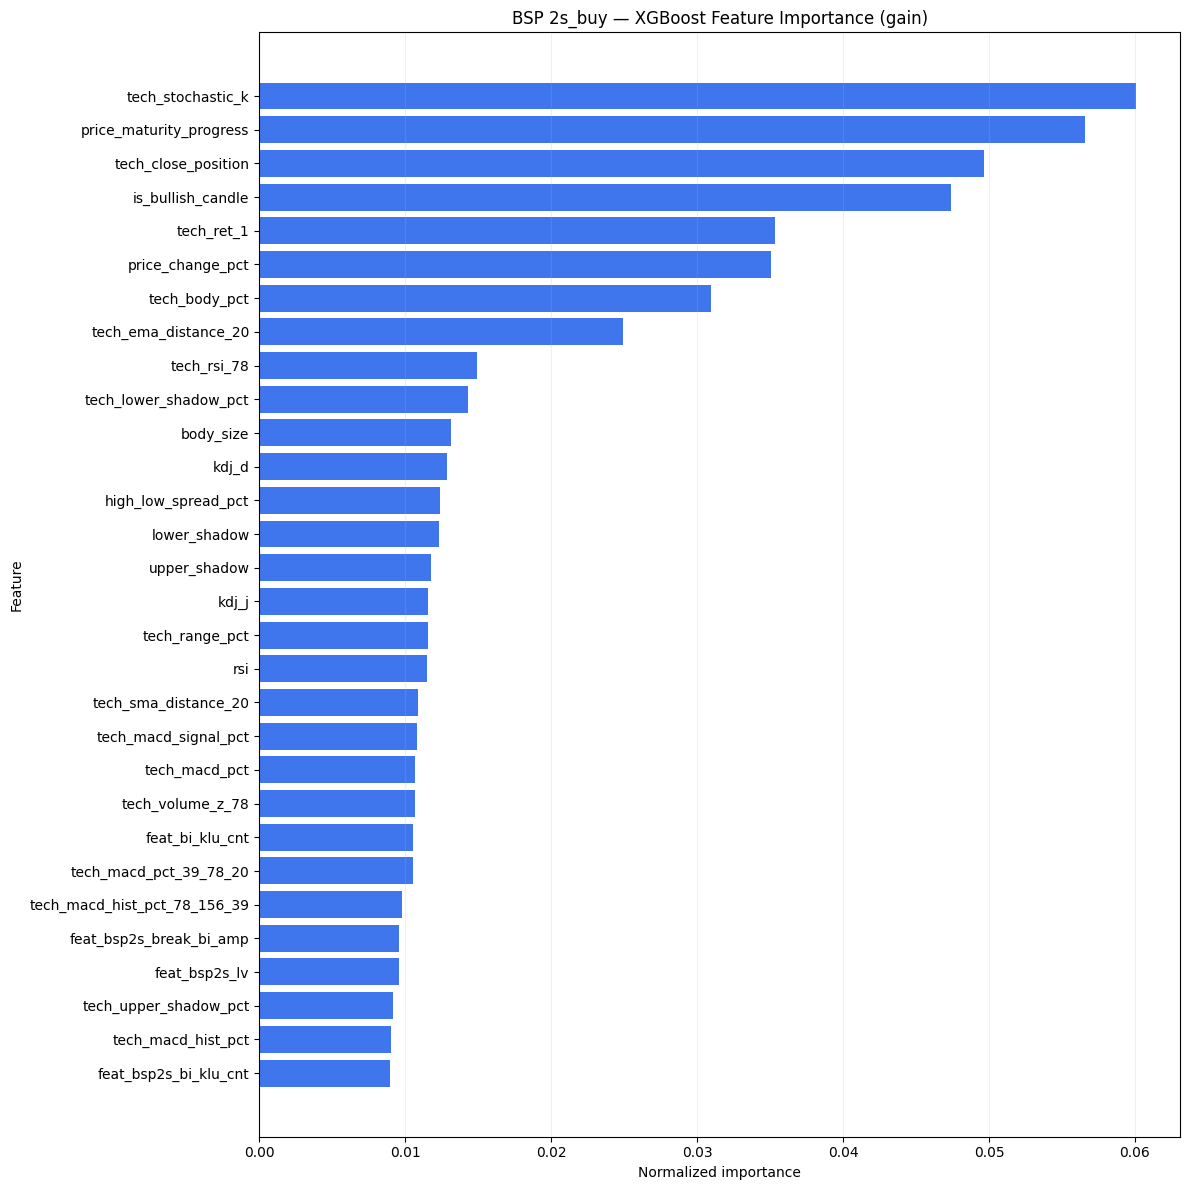

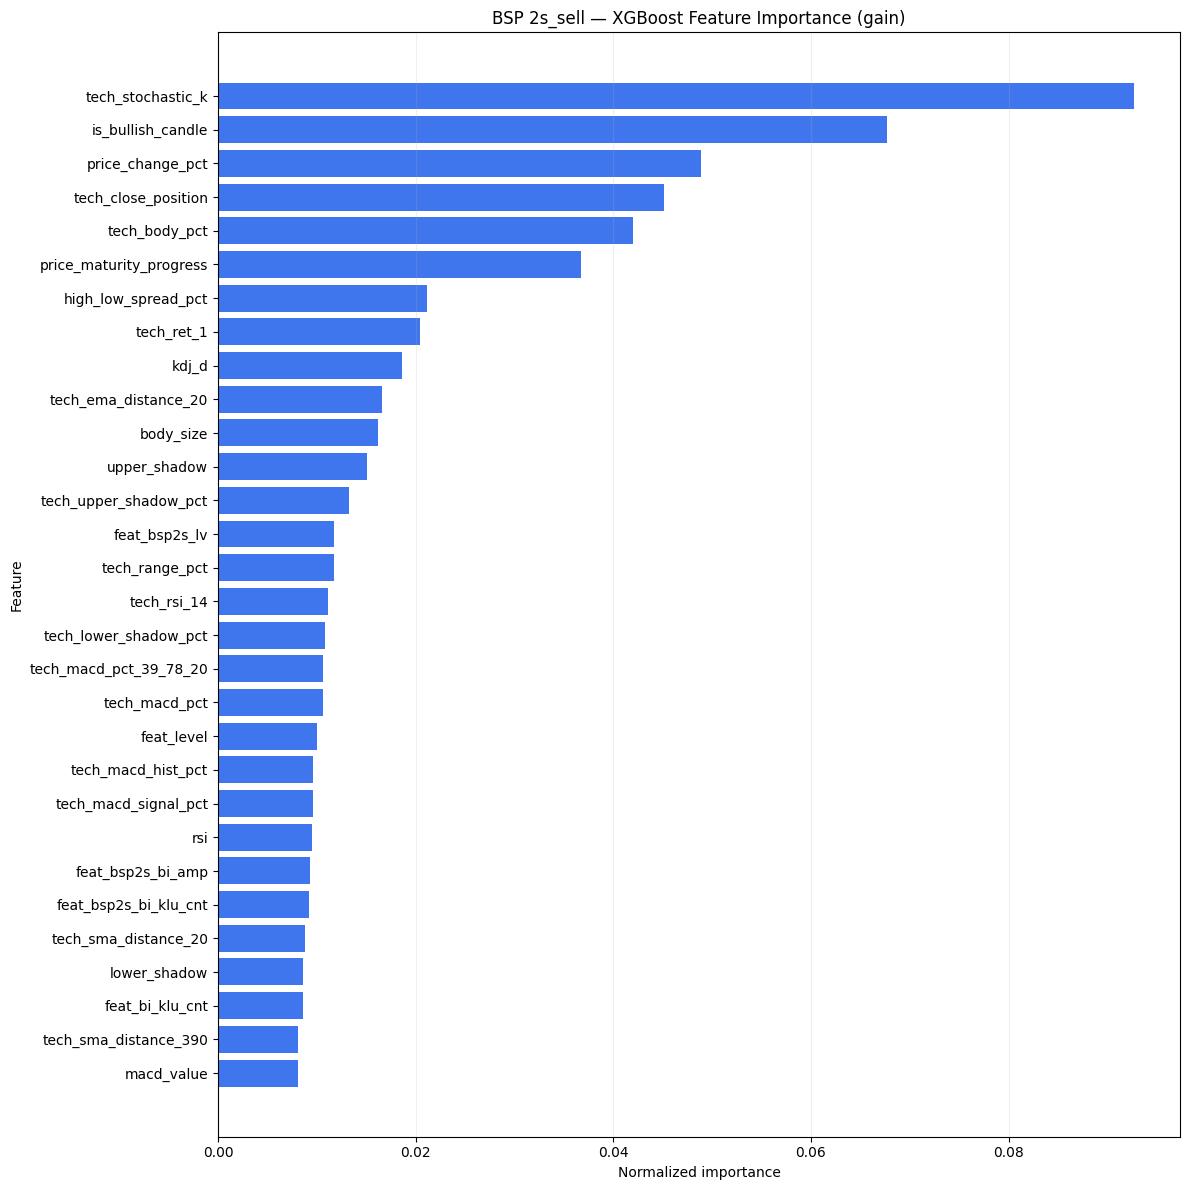

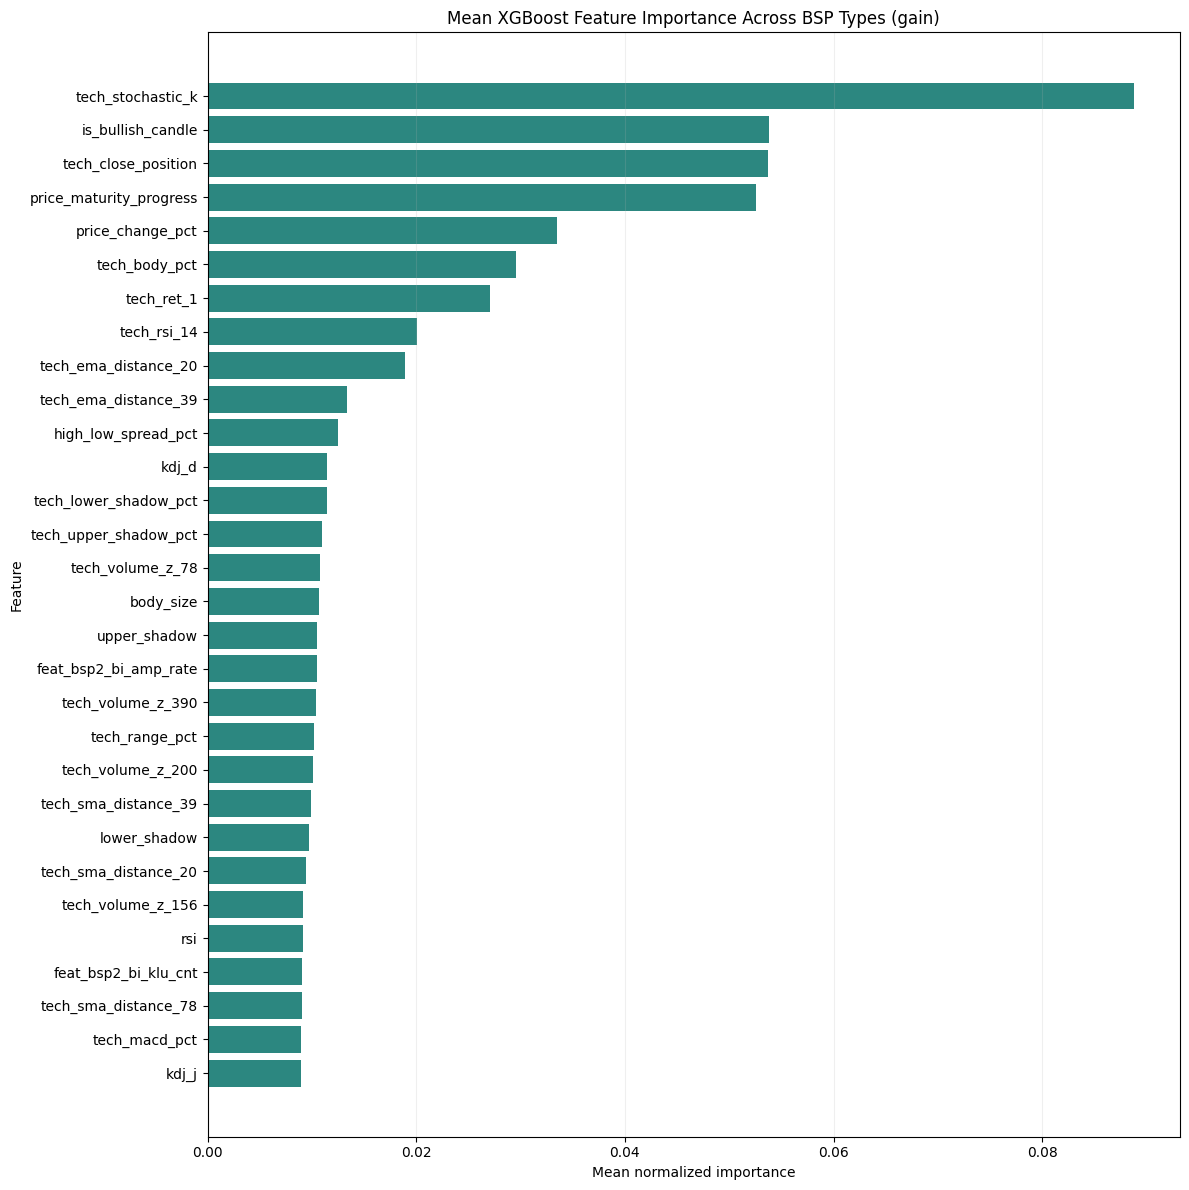

{'importance_by_type': {'1_buy':                          feature  importance bsp_type direction  rank
  0              tech_stochastic_k    0.142490        1       buy     1
  1        price_maturity_progress    0.052533        1       buy     2
  2            tech_close_position    0.052406        1       buy     3
  3              is_bullish_candle    0.038683        1       buy     4
  4                    tech_rsi_14    0.034526        1       buy     5
  ..                           ...         ...      ...       ...   ...
  91             feat_bsp2s_bi_amp    0.000000        1       buy    92
  92  feat_bsp2s_break_bi_amp_rate    0.000000        1       buy    93
  93   feat_bsp2s_break_bi_klu_cnt    0.000000        1       buy    94
  94       feat_bsp2s_break_bi_amp    0.000000        1       buy    95
  95       feat_bsp2s_retrace_rate    0.000000        1       buy    96
  
  [96 rows x 5 columns],
  '1_sell':                          feature  importance bsp_type direction  

In [46]:
import importlib
import bsp_trade_labeling

bsp_trade_labeling = importlib.reload(
    bsp_trade_labeling
)

importance_result = (
    bsp_trade_labeling
    .plot_bsp_trade_feature_importance(
        model_dir=(
            "outputs/"
            "bsp_trade_models_by_type_and_direction"
        ),
        output_dir=(
            "outputs/"
            "bsp_trade_models_by_type_and_direction/"
            "feature_importance"
        ),

        bsp_types=(
            "1",
            "1p",
            "2",
            "2s",
            # "3a",
        ),

        directions=(
            "buy",
            "sell",
        ),

        importance_type="gain",
        top_n=30,
        normalize=True,
        figsize_width=12,

        show=True,
    )
)

importance_result

In [53]:
selected_bsp_types = (
    "1",
    #"1p",
    #"2",
    #"2s",
)

start_date = "2025-01-02 09:30:00"
end_date = "2025-12-10 16:00:00"

minimum_probability = 0.85

prediction_result = (
    bsp_trade_labeling
    .create_predicted_mature_signals(
        bspoint_path=(
            "outputs/"
            "bsp_trade_labels_TQQQ_5m_"
            "2012-2026_training.csv"
        ),
        model_dir=(
            "outputs/"
            "bsp_trade_models_by_type_and_direction"
        ),

        price_csv="DataAPI/data/TQQQ_5M.csv",

        start=start_date,
        end=end_date,

        bsp_types=selected_bsp_types,

        probability_threshold=minimum_probability,

        apply_delayed_rule=False,
        apply_already_sure_rule=False,

        # Use the matching buy/sell classifier probability.
        use_price_progress_as_maturity=False,

        output_csv=(
            "outputs/"
            "predicted_bsp_directional_2025.csv"
        ),
        signals_output_csv=(
            "outputs/"
            "predicted_bsp_directional_signals_2025.csv"
        ),

        verbose=True,
    )
)

prediction_result

[BSP prediction] Models loaded: ['1_buy', '1_sell']
[BSP prediction] candidates=6,812, signals=354
[BSP prediction] All rows: C:\Users\TonyTang\Documents\chan.py\outputs\predicted_bsp_directional_2025.csv
[BSP prediction] Signals:  C:\Users\TonyTang\Documents\chan.py\outputs\predicted_bsp_directional_signals_2025.csv
bsp_type direction prediction_source  signals
       1       buy           xgboost      186
       1      sell           xgboost      168


{'output_csv': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\predicted_bsp_directional_2025.csv',
 'signals_output_csv': 'C:\\Users\\TonyTang\\Documents\\chan.py\\outputs\\predicted_bsp_directional_signals_2025.csv',
 'rows': 6812,
 'signal_rows': 354,
 'models_loaded': ['1_buy', '1_sell'],
 'missing_models': [],
 'summary':   bsp_type direction prediction_source  signals
 0        1       buy           xgboost      186
 1        1      sell           xgboost      168,
 'predictions':       klu_idx            timestamp  klu_open  klu_high  klu_low  klu_close  \
 0      495617  2025-01-02 12:25:00    39.715   39.7150  39.1550    39.2025   
 1      495618  2025-01-02 12:30:00    39.195   39.1950  38.9000    38.9689   
 2      495619  2025-01-02 12:35:00    38.960   39.0000  38.6250    38.6775   
 3      495620  2025-01-02 12:40:00    38.670   38.7825  38.4800    38.6275   
 4      495621  2025-01-02 12:45:00    38.640   38.6800  38.3600    38.3650   
 ...       ...                  

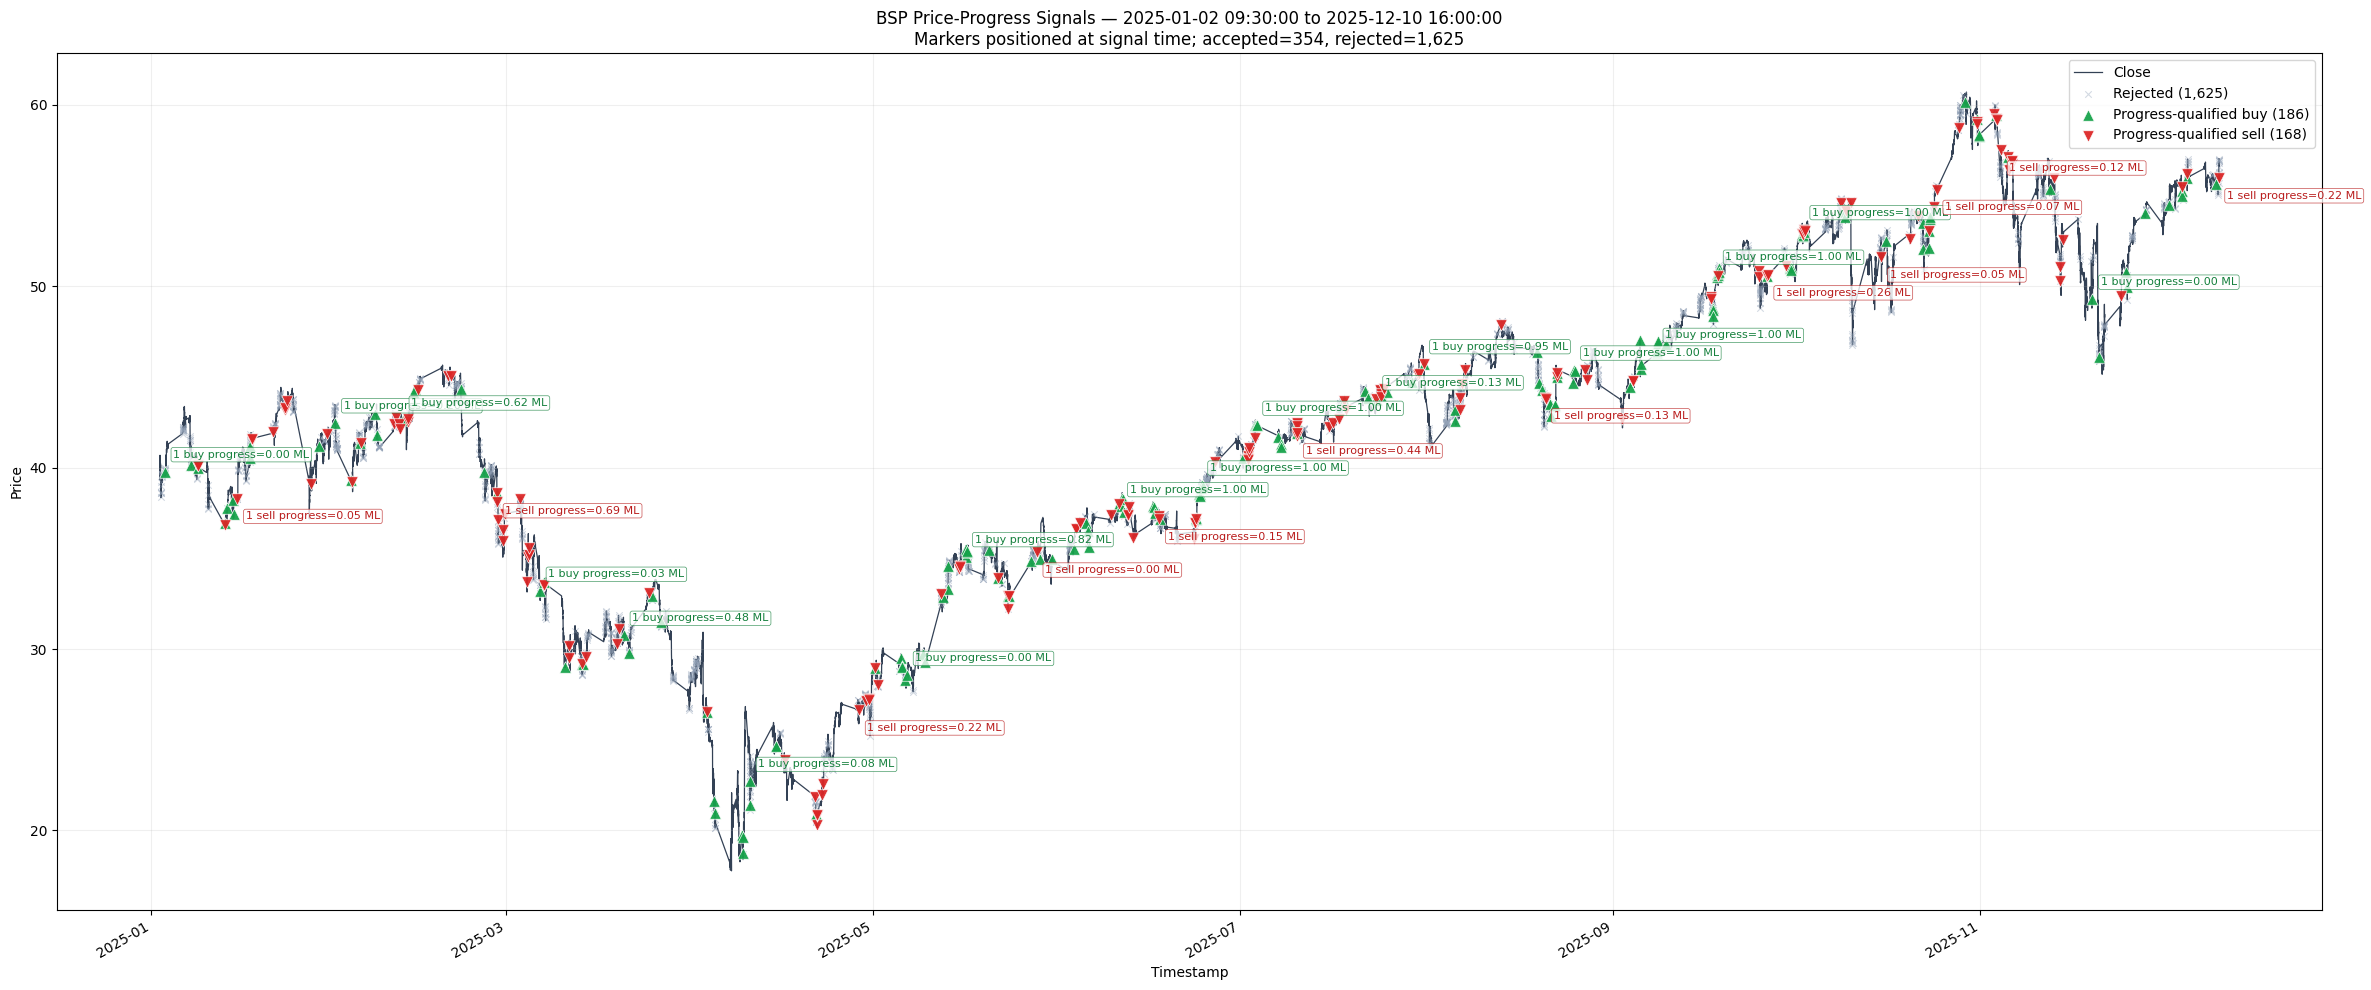

{'figure': <Figure size 2400x1000 with 1 Axes>,
 'axes': <Axes: title={'center': 'BSP Price-Progress Signals — 2025-01-02 09:30:00 to 2025-12-10 16:00:00\nMarkers positioned at signal time; accepted=354, rejected=1,625'}, xlabel='Timestamp', ylabel='Price'>,
 'predictions':       klu_idx            timestamp  klu_open  klu_high  klu_low  klu_close  \
 0      495617  2025-01-02 12:25:00   39.7150   39.7150  39.1550    39.2025   
 1      495618  2025-01-02 12:30:00   39.1950   39.1950  38.9000    38.9689   
 2      495619  2025-01-02 12:35:00   38.9600   39.0000  38.6250    38.6775   
 3      495620  2025-01-02 12:40:00   38.6700   38.7825  38.4800    38.6275   
 4      495621  2025-01-02 12:45:00   38.6400   38.6800  38.3600    38.3650   
 ...       ...                  ...       ...       ...      ...        ...   
 6804   540694  2025-12-10 15:00:00   56.8150   56.9700  56.5700    56.9200   
 6805   540695  2025-12-10 15:05:00   56.9251   56.9700  56.7300    56.9401   
 6806   540696 

In [54]:
signal_plot_result = (
    bsp_trade_labeling
    .plot_predicted_mature_signals(
        predictions_path=(
            "outputs/"
            "predicted_bsp_directional_2025.csv"
        ),
        price_csv="DataAPI/data/TQQQ_5M.csv",

        start=start_date,
        end=end_date,

        bsp_types=selected_bsp_types,

        direction=None,  # None, "buy", or "sell"
        timestamp_basis="snapshot",

        # Keep both as None because classifier filtering
        # was performed during prediction.
        minimum_probability=None,
        minimum_price_progress=None,

        annotate_max=30,
        show_rejected=True,

        output_path=(
            "outputs/"
            "predicted_bsp_directional_signals_2025.png"
        ),

        figsize=(24, 10),
        show=True,
    )
)

signal_plot_result

In [40]:
plot_result = (
    bsp_trade_labeling
    .plot_bsp_maturity_rate_and_two_day_risk(
        predictions_path=(
            "outputs/"
            "predicted_bsp_multihorizon_signals_2025.csv"
        ),
        price_csv="DataAPI/data/TQQQ_5M.csv",

        start="2025-01-02 09:30:00",
        end="2025-12-10 16:00:00",

        bsp_types=(
            "1",
            # "1p",
            # "2",
            # "2s",
            # "3a",
        ),

        direction=None,

        # Predicted future entry location
        minimum_entry_quality=0.50,

        # Current observable structural recovery
        minimum_price_progress=0.0,

        minimum_reward_risk=1.0,
        require_risk_control_pass=True,

        show_rejected=True,
        max_risk_bars=150,
        annotate_max=20,

        output_path=(
            "outputs/"
            "bsp_2d_entry_quality_and_risk_2025.png"
        ),

        show=True,
    )
)

plot_result

KeyError: "Combined prediction dataset is missing columns: ['predicted_entry_quality_2d', 'predicted_max_gain_2d', 'predicted_max_loss_2d', 'predicted_reward_risk_2d']. Run add_maturity_rate_and_two_day_risk_predictions first."

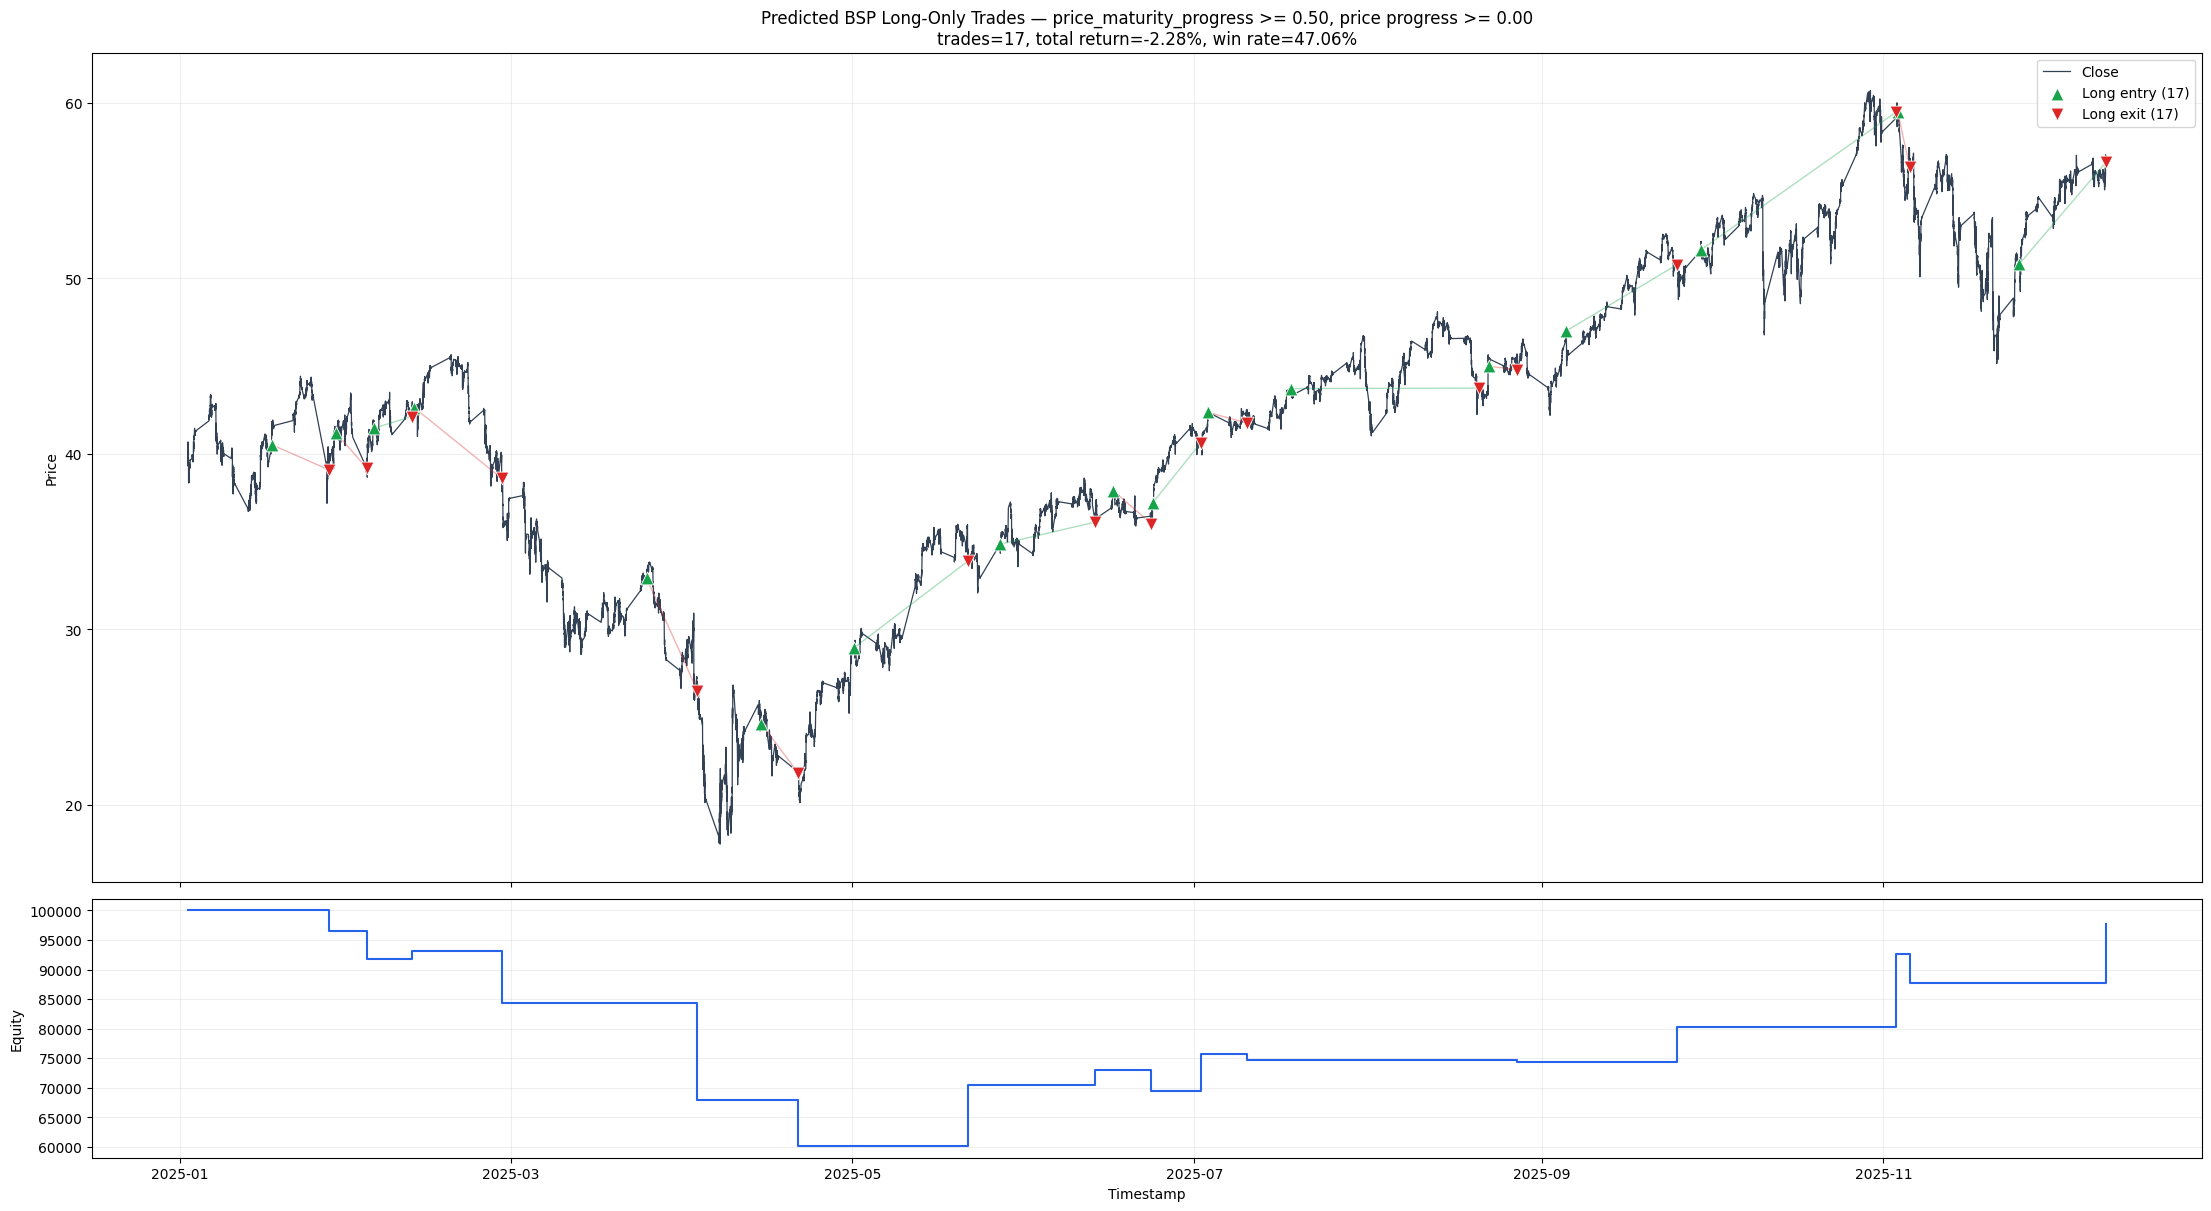

{'figure': <Figure size 2200x1200 with 2 Axes>,
 'axes': (<Axes: title={'center': 'Predicted BSP Long-Only Trades — price_maturity_progress >= 0.50, price progress >= 0.00\ntrades=17, total return=-2.28%, win rate=47.06%'}, ylabel='Price'>,
  <Axes: xlabel='Timestamp', ylabel='Equity'>),
 'events':      klu_idx            timestamp  klu_open  klu_high  klu_low  klu_close  \
 0     496158  2025-01-07 09:30:00   42.8600    42.945  42.6091    42.6150   
 1     496158  2025-01-07 09:30:00   42.8600    42.945  42.6091    42.6150   
 2     496158  2025-01-07 09:30:00   42.8600    42.945  42.6091    42.6150   
 3     496158  2025-01-07 09:30:00   42.8600    42.945  42.6091    42.6150   
 4     496409  2025-01-08 14:25:00   40.4600    40.705  40.3925    40.6325   
 ..       ...                  ...       ...       ...      ...        ...   
 148   538181  2025-11-20 10:35:00   53.2447    53.540  53.2400    53.4340   
 149   538311  2025-11-21 05:25:00   45.3500    45.385  45.1200    45.1500   

In [41]:
trade_result = (
    bsp_trade_labeling.backtest_and_plot_predicted_bsp_signals(
        predictions_path=(
            "outputs/"
            "predicted_bsp_multihorizon_2025.csv"
        ),
        price_csv="DataAPI/data/TQQQ_5M.csv",

        start="2025-01-02 09:30:00",
        end="2025-12-10 16:00:00",

        bsp_types=("1",),

        # Auto now selects price_maturity_progress.
        probability_column="auto",
        minimum_probability=0.50,

        # Optional second progress filter.
        # Keep this equal to 0 when minimum_probability
        # already represents your progress threshold.
        minimum_price_progress=0.0,

        initial_equity=100_000,
        commission_bps=1.0,
        slippage_bps=1.0,

        output_path="outputs/bsp_progress_trades_2025.png",
        trades_output_csv="outputs/bsp_progress_trades_2025.csv",

        show=True,
    )
)

trade_result

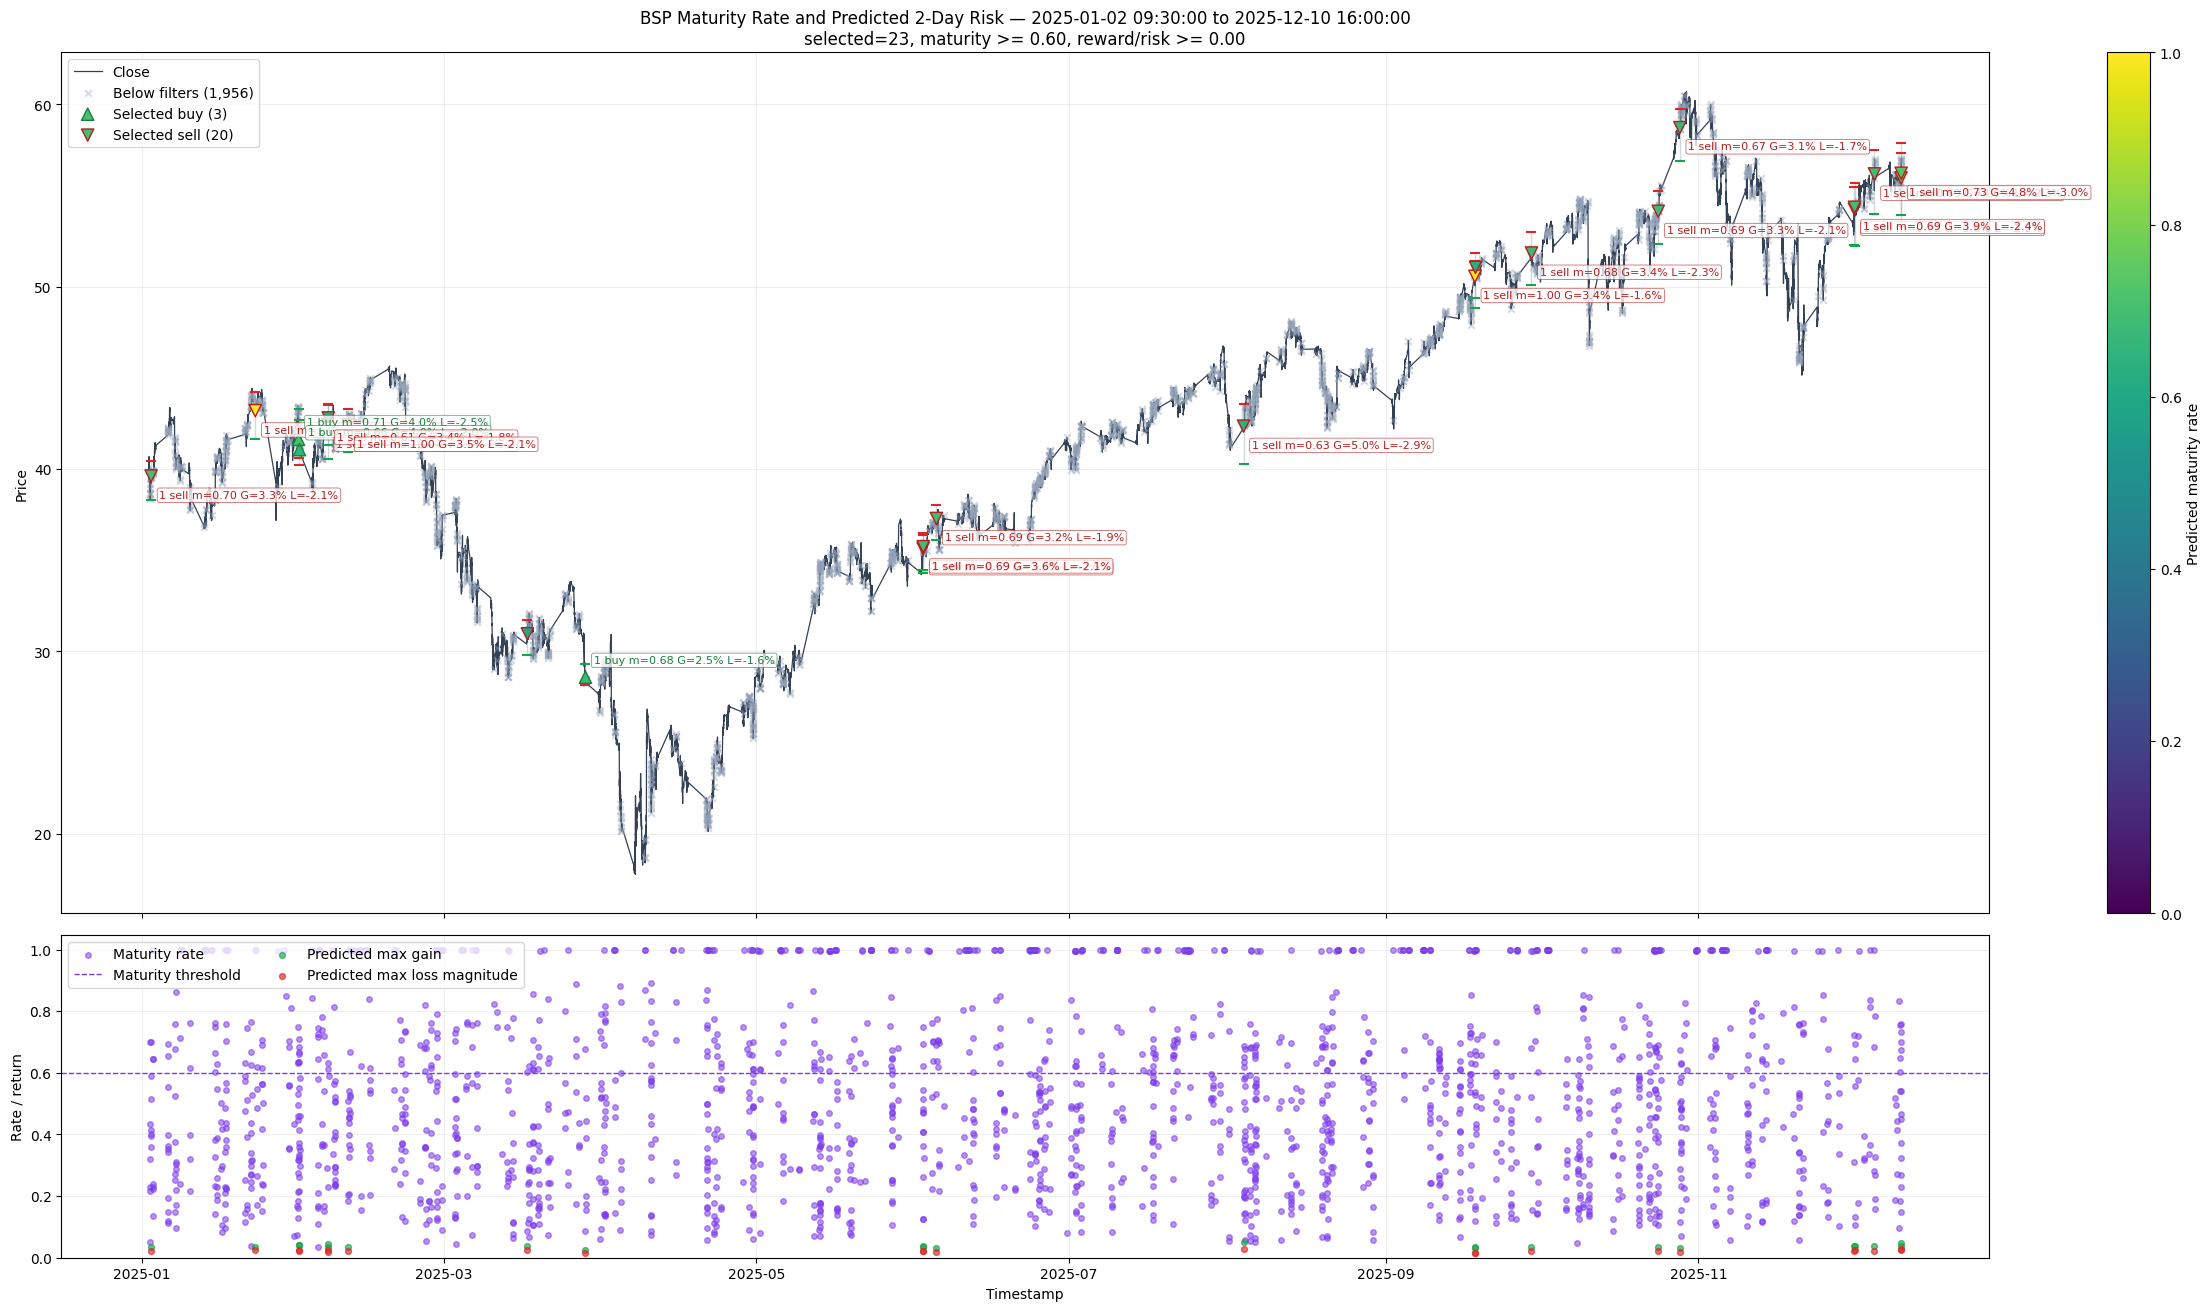

{'figure': <Figure size 2200x1300 with 3 Axes>,
 'axes': (<Axes: title={'center': 'BSP Maturity Rate and Predicted 2-Day Risk — 2025-01-02 09:30:00 to 2025-12-10 16:00:00\nselected=23, maturity >= 0.60, reward/risk >= 0.00'}, ylabel='Price'>,
  <Axes: xlabel='Timestamp', ylabel='Rate / return'>),
 'rows':       klu_idx            timestamp  klu_open  klu_high  klu_low  klu_close  \
 5      495617  2025-01-02 12:25:00   39.7150   39.7150  39.1550    39.2025   
 6      495618  2025-01-02 12:30:00   39.1950   39.1950  38.9000    38.9689   
 7      495619  2025-01-02 12:35:00   38.9600   39.0000  38.6250    38.6775   
 8      495620  2025-01-02 12:40:00   38.6700   38.7825  38.4800    38.6275   
 9      495621  2025-01-02 12:45:00   38.6400   38.6800  38.3600    38.3650   
 ...       ...                  ...       ...       ...      ...        ...   
 6809   540694  2025-12-10 15:00:00   56.8150   56.9700  56.5700    56.9200   
 6810   540695  2025-12-10 15:05:00   56.9251   56.9700  56.73

In [11]:
import importlib
import bsp_trade_labeling

importlib.invalidate_caches()
bsp_trade_labeling = importlib.reload(
    bsp_trade_labeling
)

# ---------------------------------------
# Plot controls
# ---------------------------------------

selected_bsp_types = (
    "1",
    # "1p",
    # "2",
    # "2s",
    # "3a",
)

selected_direction = None  # None, "buy", or "sell"

minimum_maturity_rate = 0.60
minimum_reward_risk = 0

start_date = "2025-01-02 09:30:00"
end_date = "2025-12-10 16:00:00"


# ---------------------------------------
# Plot maturity and two-day risk
# ---------------------------------------

risk_plot_result = (
    bsp_trade_labeling
    .plot_bsp_maturity_rate_and_two_day_risk(
        predictions_path=(
            "outputs/"
            "bsp_maturity_rate_and_2d_risk_"
            "2025-2026.csv"
        ),
        price_csv="DataAPI/data/TQQQ_5M.csv",

        start=start_date,
        end=end_date,

        bsp_types=selected_bsp_types,
        direction=selected_direction,

        minimum_maturity_rate=(
            minimum_maturity_rate
        ),
        minimum_reward_risk=(
            minimum_reward_risk
        ),

        # True additionally requires risk_control_pass.
        require_risk_control_pass=True,

        show_rejected=True,

        # Maximum number of vertical target/risk ranges.
        max_risk_bars=100,

        # Maximum number of detailed labels.
        annotate_max=20,

        output_path=(
            "outputs/"
            "bsp_maturity_rate_and_2d_risk_plot.png"
        ),

        show=True,
    )
)

risk_plot_result